In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from IPython.display import Image, display

from matplotlib.colors import LogNorm
from scipy.optimize import curve_fit
from scipy.stats import norm
from scipy.interpolate import UnivariateSpline
from collections import Counter

import gc
import itertools

In [2]:
def root_histo( ax, data, max_lim = None, min_lim = None, x_tick_loc = 2., x_tick_num = 4, box_c = [ 0.75, 0.7, 0.1, 0.2 ], step = 0.1 ) :
    if ( max_lim == None): max_lim = data.max()
    if ( min_lim == None): min_lim = data.min()
    bin_edges = np.arange( start = data.min(), stop = data.max(), step = step )
    hist, bin_edges = np.histogram( a = data, bins = bin_edges )
    errors = np.sqrt( hist )
    x_values = ( bin_edges[:-1] + bin_edges[1:] ) / 2.
    ax.errorbar( x = x_values , y = hist, yerr = errors, alpha=0.85, color='black', ecolor='gray', elinewidth=0.75, fmt='o', markersize=2.5, label = 'data' )
    ax.set_xlim( min_lim, max_lim )
    #ax.set_yscale('log')
    ax.xaxis.set_major_locator(MultipleLocator(x_tick_loc))
    ax.xaxis.set_minor_locator(AutoMinorLocator(x_tick_num))
    ax.tick_params( which = 'major', direction = 'in', length = 10, width = 1.5 )
    ax.tick_params( which = 'minor', direction = 'in', length = 5, width = 1 )
    ax.table( 
        cellText = [[f"{data.shape[0]}"],[ f"{data[data < max_lim].mean():.4f}"], [f"{data[data < max_lim].std():.4f}"], [f"{data[data < min_lim ].shape[0]}"], [f"{data[data > max_lim].shape[0]}"] ],
        rowLabels = [ 'Entries', 'Mean', 'Std Dev', 'Underflow', 'Overflow'],
        bbox = box_c,
        edges = 'open',
        rowLoc = 'left',
        )
    return ( hist, x_values )

In [3]:
# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

Old Cuts
```
    new_Ka_hyp_neg =  (  df["neg_tpc_ka"].abs() < 2 ) & \
            ( ( (df["neg_pt"].between(0, 1.4)) & (df["neg_tof_ka"].abs() < 4) ) |
              ( (df["neg_pt"].between(1.4, 2.0)) & (df["neg_tof_ka"].abs() < 2) ) |
              ( (df["neg_pt"].between(0, 2.0)) & (df["neg_tof_ka"]==-999) )
            )

    new_Ka_hyp_pos =  (  df["pos_tpc_ka"].abs() < 2 ) & \
                ( ( (df["pos_pt"].between(0, 1.4)) & (df["pos_tof_ka"].abs() < 4) ) |
                  ( (df["pos_pt"].between(1.4, 2.0)) & (df["pos_tof_ka"].abs() < 2) ) |
                  ( (df["pos_pt"].between(0, 2.0)) & (df["pos_tof_ka"]==-999) )
                )
    
    new_Pi_hyp_neg =  (  df["neg_tpc_pi"].abs() < 2 ) & \
                ( ( (df["neg_pt"].between(0, 1.4)) & (df["neg_tof_pi"].abs() < 4) ) |
                  ( (df["neg_pt"].between(1.4, 2.0)) & (df["neg_tof_pi"].abs() < 2) ) |
                  ( (df["neg_pt"].between(0, 2.0)) & (df["neg_tof_pi"]==-999) )
                )
    
    new_Pi_hyp_pos =  (  df["pos_tpc_pi"].abs() < 2 ) & \
                ( ( (df["pos_pt"].between(0, 1.4)) & (df["pos_tof_pi"].abs() < 4) ) |
                  ( (df["pos_pt"].between(1.4, 2.0)) & (df["pos_tof_pi"].abs() < 2) ) |
                  ( (df["pos_pt"].between(0, 2.0)) & (df["pos_tof_pi"]==-999) )
                )

```

Good cuts
```
    new_Ka_hyp_neg =  (  df["neg_tpc_ka"].abs() < 2 ) & \
            ( ( (df["neg_pt"].between(0, 1.4)) & (df["neg_tof_ka"].abs() < 4) ) |
              ( (df["neg_pt"].between(1.4, 3.0)) & (df["neg_tof_ka"].abs() < 3) ) |
              ( (df["neg_pt"].between(0, 3.0)) & (df["neg_tof_ka"]==-999) )
            )

    new_Ka_hyp_pos =  (  df["pos_tpc_ka"].abs() < 2 ) & \
                ( ( (df["pos_pt"].between(0, 1.4)) & (df["pos_tof_ka"].abs() < 4) ) |
                  ( (df["pos_pt"].between(1.4, 3.0)) & (df["pos_tof_ka"].abs() < 3) ) |
                  ( (df["pos_pt"].between(0, 3.0)) & (df["pos_tof_ka"]==-999) )
                )
    
    new_Pi_hyp_neg =  (  df["neg_tpc_pi"].abs() < 2 ) & \
                ( ( (df["neg_pt"].between(0, 1.4)) & (df["neg_tof_pi"].abs() < 4) ) |
                  ( (df["neg_pt"].between(1.4, 3.0)) & (df["neg_tof_pi"].abs() < 3) ) |
                  ( (df["neg_pt"].between(0, 3.0)) & (df["neg_tof_pi"]==-999) )
                )
    
    new_Pi_hyp_pos =  (  df["pos_tpc_pi"].abs() < 2 ) & \
                ( ( (df["pos_pt"].between(0, 1.4)) & (df["pos_tof_pi"].abs() < 4) ) |
                  ( (df["pos_pt"].between(1.4, 3.0)) & (df["pos_tof_pi"].abs() < 3) ) |
                  ( (df["pos_pt"].between(0, 3.0)) & (df["pos_tof_pi"]==-999) )
                )
```

Benedetto cuts
```
new_Ka_hyp_neg = ( 
          ( (df["neg_pt"].between(0, 1.5)) & (df["neg_tof_ka"].abs() < 5.67) & ( df["neg_tpc_ka"].abs() < 2.83 ) ) |
          ( (df["neg_pt"].between(1.5, 6.0)) & (df["neg_tof_ka"].abs() < 7.64) & ( df["neg_tpc_ka"].abs() < 1.5 ) ) |
          ( (df["neg_pt"].between(0, 6.0)) & (df["neg_tof_ka"]==-999) & ( df["neg_tpc_ka"].abs() < 3 ) )
        )

new_Ka_hyp_pos = (
              ( (df["pos_pt"].between(0, 1.5)) & (df["pos_tof_ka"].abs() < 5.67) & ( df["pos_tpc_ka"].abs() < 2.83 ) ) |
              ( (df["pos_pt"].between(1.5, 6.0)) & (df["pos_tof_ka"].abs() < 7.64) & ( df["pos_tpc_ka"].abs() < 1.5 ) ) |
              ( (df["pos_pt"].between(0, 6.0)) & (df["pos_tof_ka"]==-999) & ( df["pos_tpc_ka"].abs() < 3 ) )
            )

new_Pi_hyp_neg = (
              ( (df["neg_pt"].between(0, 1.5)) & (df["neg_tof_pi"].abs() < 11.56) & ( df["neg_tpc_pi"].abs() < 3.67 ) ) |
              ( (df["neg_pt"].between(1.5, 6.0)) & (df["neg_tof_pi"].abs() < 11.15) & ( df["neg_tpc_pi"].abs() < 2.0 ) ) |
              ( (df["neg_pt"].between(0, 6.0)) & (df["neg_tof_pi"]==-999) & ( df["neg_tpc_pi"].abs() < 3 ) )
            )

new_Pi_hyp_pos = (
              ( (df["pos_pt"].between(0, 1.5)) & (df["pos_tof_pi"].abs() < 11.56) & ( df["pos_tpc_pi"].abs() < 3.67 ) ) |
              ( (df["pos_pt"].between(1.5, 6.0)) & (df["pos_tof_pi"].abs() < 11.15) & ( df["pos_tpc_pi"].abs() < 2.0 ) ) |
              ( (df["pos_pt"].between(0, 6.0)) & (df["pos_tof_pi"]==-999) & ( df["pos_tpc_pi"].abs() < 3 ) )
            )
```

Final Benedetto cuts
```
new_Ka_hyp_neg = ( 
          ( (df["neg_pt"].between(0, 1.5)) & (df["neg_tof_ka"].abs() < 5.67) & ( df["neg_tpc_ka"].abs() < 2.67 ) ) |
          ( (df["neg_pt"].between(1.5, 6.0)) & (df["neg_tof_ka"].abs() < 6.51) & ( df["neg_tpc_ka"].abs() < 1.50 ) ) |
          ( (df["neg_pt"].between(0, 1.5)) & (df["neg_tof_ka"]==-999) & ( df["neg_tpc_ka"].abs() < 1.67 ) ) |
          ( (df["neg_pt"].between(1.5, 6.0)) & (df["neg_tof_ka"]==-999) & ( df["neg_tpc_ka"].abs() < 1.50 ) )
        )

new_Ka_hyp_pos = (
              ( (df["pos_pt"].between(0, 1.5)) & (df["pos_tof_ka"].abs() < 5.67) & ( df["pos_tpc_ka"].abs() < 2.67 ) ) |
              ( (df["pos_pt"].between(1.5, 6.0)) & (df["pos_tof_ka"].abs() < 6.51 & ( df["pos_tpc_ka"].abs() < 1.50 ) ) |
              ( (df["pos_pt"].between(0, 1.5)) & (df["pos_tof_ka"]==-999) & ( df["pos_tpc_ka"].abs() < 1.67 ) ) |
              ( (df["pos_pt"].between(1.5, 6.0)) & (df["pos_tof_ka"]==-999) & ( df["pos_tpc_ka"].abs() < 1.50 ) )
            )

new_Pi_hyp_neg = (
              ( (df["neg_pt"].between(0, 1.5)) & (df["neg_tof_pi"].abs() < 11.97) & ( df["neg_tpc_pi"].abs() < 3.33 ) ) |
              ( (df["neg_pt"].between(1.5, 6.0)) & (df["neg_tof_pi"].abs() < 10.74) & ( df["neg_tpc_pi"].abs() < 2.17 ) ) |
              ( (df["neg_pt"].between(0, 1.5)) & (df["neg_tof_pi"]==-999) & ( df["neg_tpc_pi"].abs() < 3.00 ) ) |
              ( (df["neg_pt"].between(1.5, 6.0)) & (df["neg_tof_pi"]==-999) & ( df["neg_tpc_pi"].abs() < 2.00 ) )
            )

new_Pi_hyp_pos = (
              ( (df["pos_pt"].between(0, 1.5)) & (df["pos_tof_pi"].abs() < 11.97) & ( df["pos_tpc_pi"].abs() < 3.33 ) ) |
              ( (df["pos_pt"].between(1.5, 6.0)) & (df["pos_tof_pi"].abs() < 10.74) & ( df["pos_tpc_pi"].abs() < 2.17 ) ) |
              ( (df["pos_pt"].between(0, 1.5)) & (df["pos_tof_pi"]==-999) & ( df["pos_tpc_pi"].abs() < 3.0 ) ) |
              ( (df["pos_pt"].between(1.5, 6.0)) & (df["pos_tof_pi"]==-999) & ( df["pos_tpc_pi"].abs() < 2.0 ) )
            )

```

In [4]:
bucket = []

files = !ls Big*.pkl

for item in files:
    df = pd.read_pickle(item)
    COS_pre_mask = df["cos_pointing"] > 0.50
    df = df[COS_pre_mask]
    
    print("Processing ", item)
    new_Ka_hyp_neg = ( 
              ( (df["neg_pt"].between(0, 1.5)) & (df["neg_tof_ka"].abs() < 5.67) & ( df["neg_tpc_ka"].abs() < 2.67 ) ) |
              ( (df["neg_pt"].between(1.5, 6.0)) & (df["neg_tof_ka"].abs() < 6.51) & ( df["neg_tpc_ka"].abs() < 1.50 ) ) |
              ( (df["neg_pt"].between(0, 1.5)) & (df["neg_tof_ka"]==-999) & ( df["neg_tpc_ka"].abs() < 1.67 ) ) |
              ( (df["neg_pt"].between(1.5, 6.0)) & (df["neg_tof_ka"]==-999) & ( df["neg_tpc_ka"].abs() < 1.50 ) )
            )
    
    new_Ka_hyp_pos = (
                  ( (df["pos_pt"].between(0, 1.5)) & (df["pos_tof_ka"].abs() < 5.67) & ( df["pos_tpc_ka"].abs() < 2.67 ) ) |
                  ( (df["pos_pt"].between(1.5, 6.0)) & (df["pos_tof_ka"].abs() < 6.51) & ( df["pos_tpc_ka"].abs() < 1.50 ) ) |
                  ( (df["pos_pt"].between(0, 1.5)) & (df["pos_tof_ka"]==-999) & ( df["pos_tpc_ka"].abs() < 1.67 ) ) |
                  ( (df["pos_pt"].between(1.5, 6.0)) & (df["pos_tof_ka"]==-999) & ( df["pos_tpc_ka"].abs() < 1.50 ) )
                )
    
    new_Pi_hyp_neg = (
                  ( (df["neg_pt"].between(0, 1.5)) & (df["neg_tof_pi"].abs() < 11.97) & ( df["neg_tpc_pi"].abs() < 3.33 ) ) |
                  ( (df["neg_pt"].between(1.5, 6.0)) & (df["neg_tof_pi"].abs() < 10.74) & ( df["neg_tpc_pi"].abs() < 2.17 ) ) |
                  ( (df["neg_pt"].between(0, 1.5)) & (df["neg_tof_pi"]==-999) & ( df["neg_tpc_pi"].abs() < 3.00 ) ) |
                  ( (df["neg_pt"].between(1.5, 6.0)) & (df["neg_tof_pi"]==-999) & ( df["neg_tpc_pi"].abs() < 2.00 ) )
                )
    
    new_Pi_hyp_pos = (
                  ( (df["pos_pt"].between(0, 1.5)) & (df["pos_tof_pi"].abs() < 11.97) & ( df["pos_tpc_pi"].abs() < 3.33 ) ) |
                  ( (df["pos_pt"].between(1.5, 6.0)) & (df["pos_tof_pi"].abs() < 10.74) & ( df["pos_tpc_pi"].abs() < 2.17 ) ) |
                  ( (df["pos_pt"].between(0, 1.5)) & (df["pos_tof_pi"]==-999) & ( df["pos_tpc_pi"].abs() < 3.0 ) ) |
                  ( (df["pos_pt"].between(1.5, 6.0)) & (df["pos_tof_pi"]==-999) & ( df["pos_tpc_pi"].abs() < 2.0 ) )
                )
    
    new_undecided_neg = new_Ka_hyp_neg & new_Pi_hyp_neg
    new_undecided_pos = new_Ka_hyp_pos & new_Pi_hyp_pos
    new_undecided_hyp = new_undecided_neg & new_undecided_pos
    
    new_Ka_hyp = new_Ka_hyp_neg | new_Ka_hyp_pos
    new_Pi_hyp = new_Pi_hyp_pos | new_Pi_hyp_neg
    
    new_D0_sure_hyp = new_Ka_hyp_neg & new_Pi_hyp_pos
    new_D0_uncert_hyp = ( (new_undecided_neg & new_Pi_hyp_pos) | (new_undecided_pos & new_Ka_hyp_neg) )
    new_D0 = new_D0_sure_hyp | new_D0_uncert_hyp
    
    new_antiD0_sure_hyp = new_Ka_hyp_pos & new_Pi_hyp_neg
    new_antiD0_uncert_hyp = ( (new_undecided_neg & new_Ka_hyp_pos) | (new_undecided_pos & new_Pi_hyp_neg) )
    new_antiD0 = new_antiD0_sure_hyp | new_antiD0_uncert_hyp
    
    df["new_particle"] = np.select( condlist=[new_undecided_hyp, new_D0, new_antiD0 ],
                                    choicelist=["Undecided", "D0", "Anti-D0"], default="Bkg" )
    signal_mask = df["new_particle"] != "Bkg"
    

    bucket.append(df.loc[signal_mask,["dcaXY_product", "inv_mass", "anti_mass", "pt", "decay_length", "cos_pointing", "new_particle"]] )
    #bucket.append(df.loc[signal_mask,["dcaXY_product", "inv_mass", "anti_mass", "pt", "cos_pointing", "new_particle"]] )
    del df
    gc.collect()

Processing  Big_Chunk0950.pkl
Processing  Big_Chunk1000.pkl
Processing  Big_Chunk1010.pkl
Processing  Big_Chunk1020.pkl
Processing  Big_Chunk1030.pkl
Processing  Big_Chunk1040.pkl
Processing  Big_Chunk1050.pkl
Processing  Big_Chunk1100.pkl
Processing  Big_Chunk1110.pkl
Processing  Big_Chunk1120_001_005.pkl
Processing  Big_Chunk1120_006_011.pkl
Processing  Big_Chunk1130_pt1.pkl
Processing  Big_Chunk1130_pt2.pkl
Processing  Big_Chunk1130_pt3.pkl
Processing  Big_Chunk1140_001_006.pkl
Processing  Big_Chunk1140_007_011.pkl
Processing  Big_Chunk1150_pt1.pkl
Processing  Big_Chunk1150_pt2.pkl
Processing  Big_Chunk1200_pt1.pkl
Processing  Big_Chunk1200_pt2.pkl
Processing  Big_Chunk1200_pt3.pkl
Processing  Big_Chunk1200_pt4.pkl
Processing  Big_Chunk1210_pt1.pkl
Processing  Big_Chunk1210_pt2.pkl
Processing  Big_Chunk1210_pt3.pkl
Processing  Big_Chunk1220_pt1.pkl
Processing  Big_Chunk1220_pt2.pkl
Processing  Big_Chunk1220_pt3.pkl
Processing  Big_Chunk1300_pt1.pkl
Processing  Big_Chunk1300_pt2.pkl


In [5]:
df = pd.concat(bucket, ignore_index=True)
df.columns

Index(['dcaXY_product', 'inv_mass', 'anti_mass', 'pt', 'decay_length',
       'cos_pointing', 'new_particle'],
      dtype='object')

benedetto pair variables
```
let's define the cuts for each pt window:
cuts_config = [
    # pt ∈ [0, 1.5]
    dict(
        cos_pointing = 0.5861,
        dcaXY_product = 2e-5
        # no decay_length cut here
    ),
    
    # pt ∈ [1.5, 3]
    dict(
        cos_pointing = 0.7880,
        dcaXY_product = -1.578e-05
        # no decay_length cut here
    ),
    
    # pt ∈ [3, 16]
    dict(
        cos_pointing = 0.9836,
        dcaXY_product = -1.774e-05,
        decay_length = 0.0071
    )
]
```

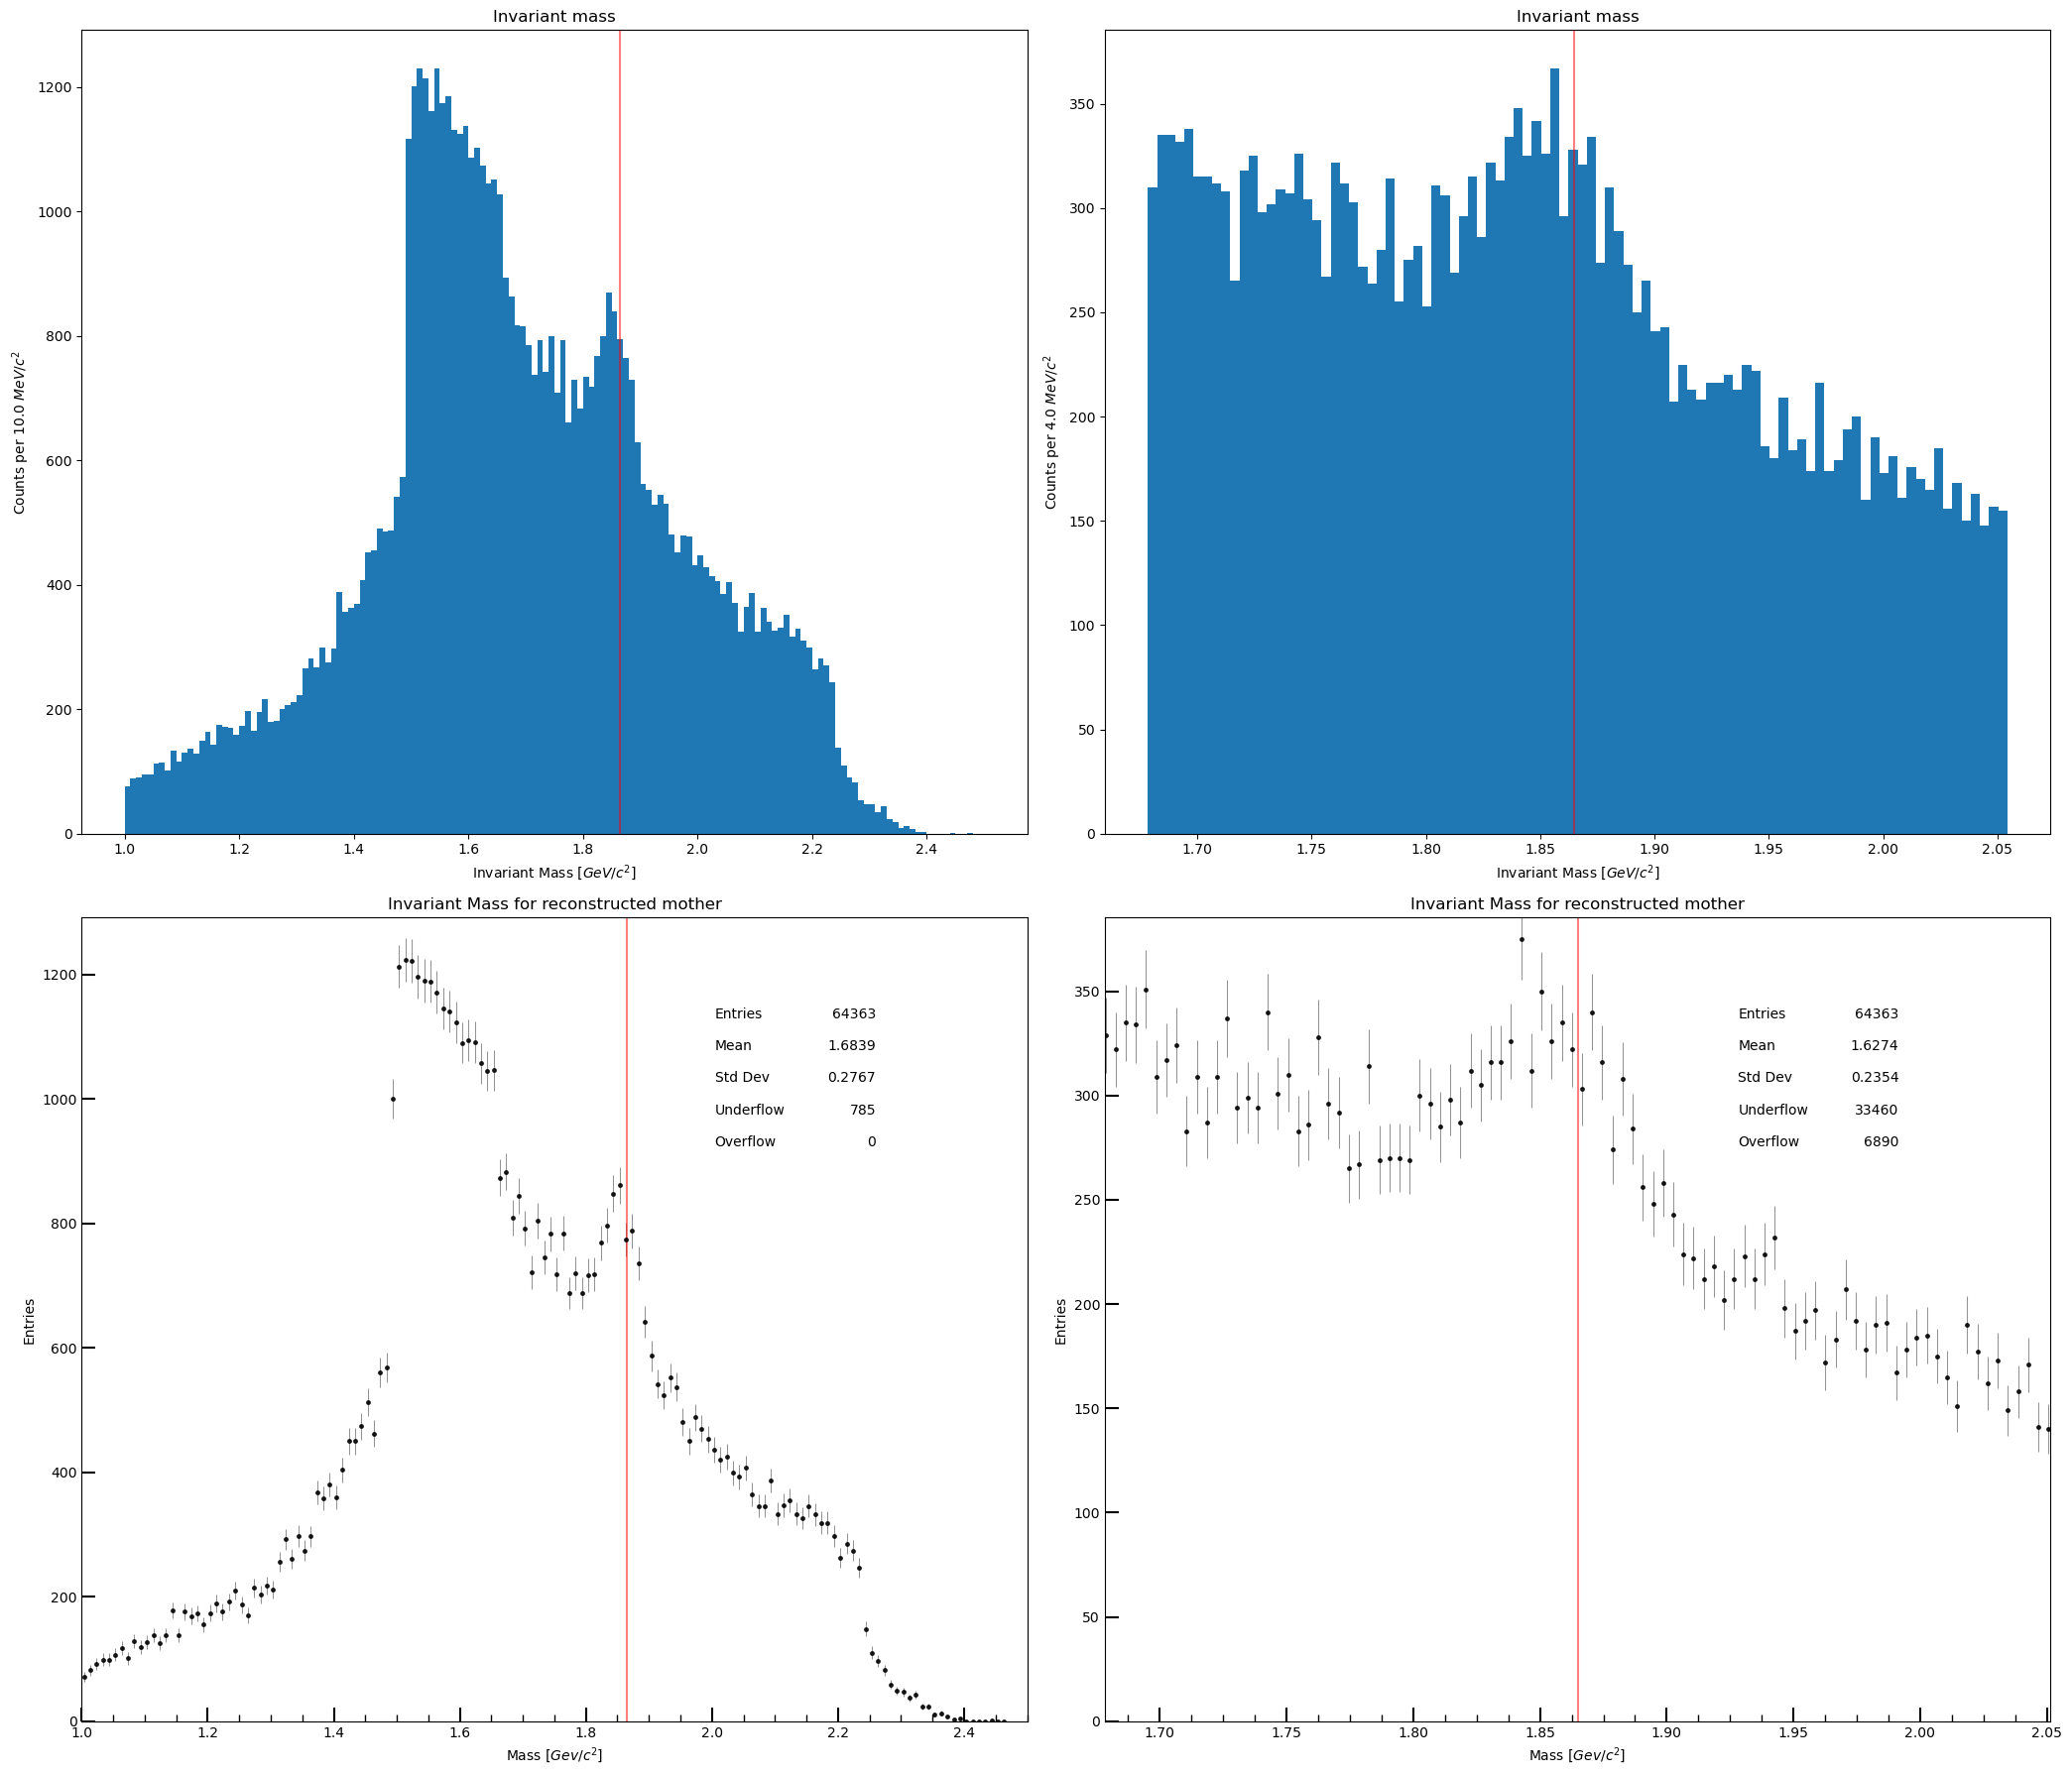

In [6]:
# Now with some filtering
COS_CUT = 0.9836
PT_MIN, PT_MAX = 3, 16

pt_mask = df["pt"].between(PT_MIN, PT_MAX )
cos_mask = (df["cos_pointing"] > COS_CUT)
# dca_mask = ( (df["pt"] < 3) & (df["dcaXY_product"] < -2.264e-05) ) | ( (df["pt"].between(3,8)) & (df["dcaXY_product"] < -2.250e-05) )
# decayL_mask = ( df["decay_length"] > 0.0070 )

dca_mask = df["dcaXY_product"] < -1.774e-05
decayL_mask = df["decay_length"] > 0.0071


mask =  pt_mask & cos_mask & dca_mask & decayL_mask
filtered_df = df[mask]

filtered_masses = np.concatenate([filtered_df[filtered_df["new_particle"]=="D0"]["inv_mass"],
                                  filtered_df[filtered_df["new_particle"]=="Anti-D0"]["anti_mass"],
                                  filtered_df[filtered_df["new_particle"]=="Undecided"]["inv_mass"],
                                  filtered_df[filtered_df["new_particle"]=="Undecided"]["anti_mass"]])

fig, ax = plt.subplots(2,2, figsize=(21,9*2) )
MASS_MIN, MASS_MAX = 1, 2.5
binwidth = 0.01
ax[0][0].hist(filtered_masses,range=(MASS_MIN,MASS_MAX), bins=np.arange(MASS_MIN, MASS_MAX+binwidth,binwidth))
ax[0][0].axvline(x=m_d0, color="red", alpha=0.5)
ax[0][0].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[0][0].set_ylabel(f"Counts per {binwidth*1000:.1f} $MeV/c^2$")
ax[0][0].set_title(f"Invariant mass")
lim_y = ax[0][0].get_ylim()

M_min, M_max = 0.9*m_d0, 1.1*m_d0
binwidth_zoom = 0.004
ax[0][1].hist(filtered_masses,range=(M_min,M_max), bins=np.arange(M_min, M_max+binwidth_zoom,binwidth_zoom))
ax[0][1].axvline(x=m_d0, color="red", alpha=0.5)
ax[0][1].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[0][1].set_ylabel(f"Counts per {(binwidth_zoom*1000):.1f} $MeV/c^2$")
ax[0][1].set_title(f"Invariant mass")
#plt.savefig("Maybe.png")
lim_y_zoom = ax[0][1].get_ylim()

_ = root_histo( ax[1][0], data=filtered_masses, max_lim = MASS_MAX , min_lim = MASS_MIN ,step = binwidth,
                box_c = [ 0.75, 0.7, 0.1, 0.2 ], x_tick_loc = 0.2 )
ax[1][0].set_title( "Invariant Mass for reconstructed mother" )
ax[1][0].set_xlabel( r"Mass $[Gev/c^2]$")
ax[1][0].set_ylabel( r"Entries")
ax[1][0].axvline(x=m_d0, color="red", alpha=0.5)
ax[1][0].set_ylim(lim_y)

_ = root_histo( ax[1][1], data=filtered_masses, max_lim = M_max, min_lim = M_min, step=binwidth_zoom,
                box_c = [ 0.75, 0.7, 0.1, 0.2 ], x_tick_loc = 0.05 )
ax[1][1].set_title( "Invariant Mass for reconstructed mother" )
ax[1][1].set_xlabel( r"Mass $[Gev/c^2]$")
ax[1][1].set_ylabel( r"Entries" )
ax[1][1].axvline(x=m_d0, color="red", alpha=0.5)
ax[1][1].set_ylim(lim_y_zoom)

plt.savefig("All_Good_Data.png")
plt.tight_layout()
plt.show()

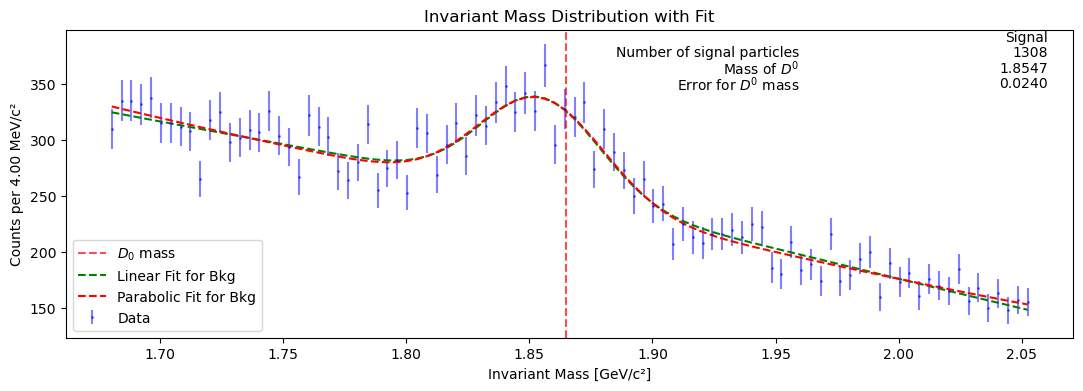

In [7]:
ratio = 0.75503   # fixed ratio from the same cuts in MC
# values from MC
mu_reflex = 1.859173
sigma_reflex = 0.119332

def fit_function(x, k, mu1, sigma1, a, b):
    reflex_part  = norm.pdf(x, loc=mu_reflex, scale=sigma_reflex)
    signal_part  = norm.pdf(x, loc=mu1,       scale=sigma1)
    background   = a*x + b
    return k * ( ratio*reflex_part + signal_part) + background

def fit_function_par(x, k, mu1, sigma1, a, b, c):
    reflex_part  = norm.pdf(x, loc=mu_reflex, scale=sigma_reflex)
    signal_part  = norm.pdf(x, loc=mu1,       scale=sigma1)
    background   = a*x**2 + b*x + c
    return k * ( ratio*reflex_part + signal_part) + background


# INITIALIZATIONS:
MIN_MASS, MAX_MASS = M_min, M_max
N_BINS = 150
binsize = binwidth_zoom

# Initial parameter guesses
k_param       = 100
signal_params = [m_d0, 0.02]
back_params   = [133, 1000]

# Parameter guess
back_params_par   = [133, 1000, 0]

# --- Data ---
data = filtered_masses

# HISTOGRAM:
fig, ax = plt.subplots(figsize=(13,4))
both_counts, both_edges = np.histogram(data, bins=np.arange(MIN_MASS, MAX_MASS+binwidth_zoom,binwidth_zoom), range=(MIN_MASS, MAX_MASS))
both_centers = (both_edges[:-1] + both_edges[1:]) / 2.0
# --- Poisson errors ---
sigma_hist = np.sqrt(both_counts)
sigma_hist = np.clip(sigma_hist, 1, None)
# plot:
ax.errorbar(both_centers, both_counts, yerr=sigma_hist, fmt='.', markersize=2, color='blue', alpha=0.5, label='Data')
ax.axvline(x=m_d0, color="red", ls='--', label=r"$D_0$ mass", alpha=0.7)

# FIT:
both_fit_res = curve_fit(
    f       = fit_function,
    xdata   = both_centers,
    ydata   = both_counts,
    sigma   = sigma_hist,
    p0      = [
        k_param,                # 0: k
        signal_params[0],       # 1: mu1
        signal_params[1],       # 2: sigma1
        back_params[0],         # 3: a
        back_params[1]          # 4: b
    ]
)

both_fit_res_par = curve_fit(
    f       = fit_function_par,
    xdata   = both_centers,
    ydata   = both_counts,
    sigma   = sigma_hist,
    p0      = [
        k_param,                # 0: k
        signal_params[0],       # 1: mu1
        signal_params[1],       # 2: sigma1
        back_params_par[0],         # 3: a
        back_params_par[1],          # 4: b
        back_params_par[2]          # 5: c
    ]
)

both_params = both_fit_res[0]
k_fit, mu1, sigma1, a_fit, b_fit = both_params

both_params_par = both_fit_res_par[0]
k_fit_par, mu1_par, sigma1_par, a_fit_par, b_fit_par, c_fit_par = both_params_par

# PLOT fitted curve:
ax.plot( both_centers, fit_function(both_centers, *both_params),
    color='green', linestyle='dashed', linewidth=1.5, label='Linear Fit for Bkg'
)

ax.plot( both_centers, fit_function_par(both_centers, *both_params_par),
    color='red', linestyle='dashed', linewidth=1.5, label='Parabolic Fit for Bkg'
)

# COUNT of D0 from the signal Gaussian only:
mass_from_fit  = mu1
sigma_from_fit = sigma1
counts_from_fit =  ( k_fit * (norm.cdf(MAX_MASS, loc=mu1, scale=sigma1) - norm.cdf(MIN_MASS, loc=mu1, scale=sigma1)) ) / binsize

mass_from_fit_par  = mu1_par
sigma_from_fit_par = sigma1_par
counts_from_fit_par =  ( k_fit_par * (norm.cdf(MAX_MASS, loc=mu1_par, scale=sigma1_par) - norm.cdf(MIN_MASS, loc=mu1_par, scale=sigma1_par)) ) / binsize

# TABLE INSIDE PLOT:
ax.table(
    cellText = [[f"{counts_from_fit:.0f}"], [f"{mass_from_fit:.4f}"], [f"{sigma_from_fit:.4f}"]],
    rowLabels = [r'Number of signal particles', r'Mass of $D^0$', r'Error for $D^0$ mass'],
    colLabels = ['Signal'],
    colLoc = "right",
    bbox = [0.75, 0.8, 0.25, 0.2],
    edges = 'open',
    rowLoc = 'right'
)

ax.set_xlabel("Invariant Mass [GeV/c²]")
ax.set_ylabel(f"Counts per {binsize*1000:.2f} MeV/c²")
ax.set_title("Invariant Mass Distribution with Fit")
ax.legend(loc='lower left')
plt.show()

In [8]:
print("Linear Bkg:",counts_from_fit)
print("Parabolic Bkg:", counts_from_fit_par)

Linear Bkg: 1307.5506085011018
Parabolic Bkg: 1459.7612511861248


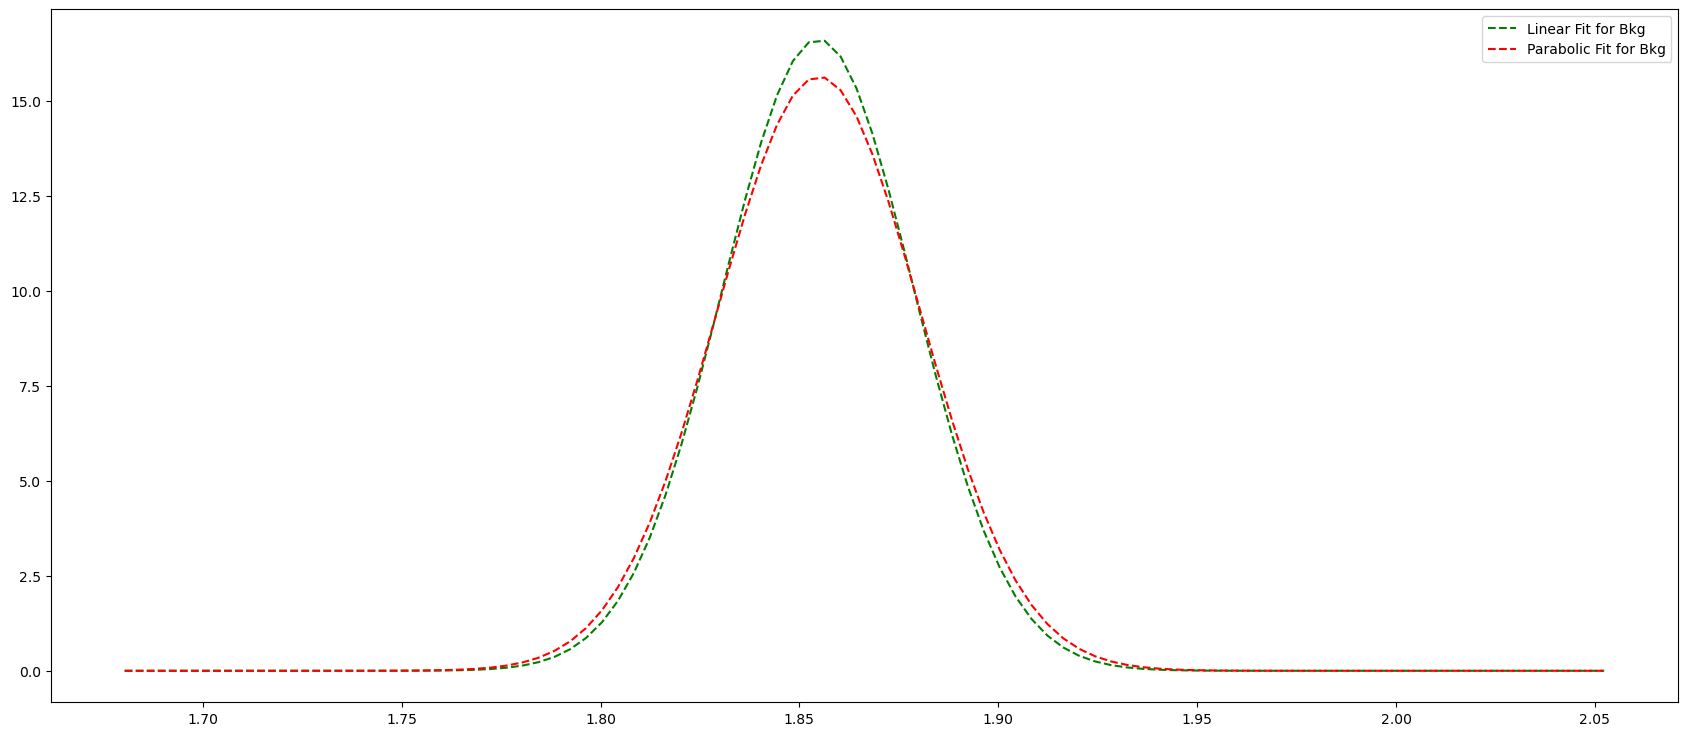

In [9]:
# PLOT fitted curve:
fig, ax = plt.subplots(figsize=(21,9))
ax.plot( both_centers, norm.pdf(both_centers, loc=mass_from_fit, scale=sigma_from_fit),
    color='green', linestyle='dashed', linewidth=1.5, label='Linear Fit for Bkg'
)

ax.plot( both_centers, norm.pdf(both_centers, loc=mass_from_fit_par, scale=sigma_from_fit_par),
    color='red', linestyle='dashed', linewidth=1.5, label='Parabolic Fit for Bkg'
)
plt.legend()
plt.show()